# Mode matching a laser to a Fabry-Perot cavity

We want to mode match a laser to a two-mirror Fabry-Perot cavity.
The cavity sits 3 m from the laser, and the two lenses are picked
from a stock of focal lengths.

| | |
|---|---|
| Cavity | L = 1 m, ROC 2.5 m (input mirror) and 1.5 m (end mirror) |
| Laser | waist diameter 0.2 mm, 3 m of path to the cavity |
| Free parameters | positions and focal lengths of the two lenses |

The plan: find the eigenmode of the cavity first, then build the
actual bench in gtrace, where the lenses have thickness and the
input mirror is a real substrate, and let the trace itself say how
good the coupling is.

In [1]:
import numpy as np
import gtrace.beam as beam
import gtrace.optcomp as opt
import gtrace.optics.gaussian as gauss
from gtrace.layout import OpticalLayout, TraceRules
from gtrace.unit import *

import matplotlib.pyplot as plt

wl = 1064*nm
w0_laser = 0.2*mm            # radius: the spec quotes the diameter

## The eigenmode of the cavity

Two mirrors of radii $R_1$, $R_2$ a distance $L$ apart, with
$g_i = 1 - L/R_i$, form a stable cavity when $0 < g_1 g_2 < 1$.
The waist sits $z_1 = \frac{g_2(1-g_1)}{g_1+g_2-2g_1g_2}L$ from the
input mirror, and the Rayleigh range is
$z_R = \sqrt{\frac{g_1g_2(1-g_1g_2)}{(g_1+g_2-2g_1g_2)^2}}\,L$.

In [2]:
L_cav = 1.0
R1, R2 = 2.5, 1.5
g1, g2 = 1 - L_cav/R1, 1 - L_cav/R2
assert 0 < g1*g2 < 1, 'the cavity would not be stable'

denom = g1 + g2 - 2*g1*g2
z1 = g2*(1 - g1)/denom * L_cav          # waist, measured from the ITM
zr_cav = np.sqrt(g1*g2*(1 - g1*g2))/denom * L_cav
w0_cav = gauss.zr2w0(zr_cav, wl=wl)

print('g1 g2      = %.3f' % (g1*g2))
print('waist      : %.3f m from the input mirror' % z1)
print('w0 (cavity): %.4f mm   (Rayleigh range %.3f m)'
      % (w0_cav/mm, zr_cav))
print('w0 (laser) : %.4f mm   (Rayleigh range %.4f m)'
      % (w0_laser/mm, gauss.w02zr(w0_laser, wl=wl)))

g1 g2      = 0.200
waist      : 0.250 m from the input mirror
w0 (cavity): 0.5040 mm   (Rayleigh range 0.750 m)
w0 (laser) : 0.2000 mm   (Rayleigh range 0.1181 m)


## Confirming the eigenmode by ray tracing

The formulas above are the textbook eigenmode of a two-mirror cavity.
gtrace can pull the same answer out of a ray trace. A GaussianBeam
object carries the attributes Mx and My: the ABCD transformations the
beam has received while propagating, accumulated as a product. On a
newly created beam they are initialised to the identity matrix.

So send such a beam once around the cavity and its Mx is the
round-trip ABCD matrix. Put a fresh beam on the surface of the ITM,
propagate it to the ETM and reflect it, reflect the returning beam at
the ITM, and read Mx and My off the beam object right after that
reflection. In a system without astigmatism the two must agree.
Writing the matrix elements as
$$
\begin{pmatrix}
A & B \\
C & D
\end{pmatrix}
$$
the eigenmode is the mode that returns to itself after one round
trip, so

$$q = \frac{Aq + B}{Cq + D}$$

is to be solved for $q$ (the roots of $Cq^2 + (D-A)q - B = 0$).
There are two; take the one whose imaginary part (= the Rayleigh
range) is positive.

When Mx and My differ, the eigenmode carries a different q in the x
and y directions.

In [3]:
#Only the two cavity mirrors, as probes.
ITM = opt.Mirror(HRcenter=[3, 0], normAngleHR=0,
                 diameter=1*inch, thickness=6*mm, wedgeAngle=0.0,
                 inv_ROC_HR=1./R1, Refl_HR=0.9, Trans_HR=0.1,
                 name='ITM')
ETM = opt.Mirror(HRcenter=[3 + L_cav, 0], normAngleHR=np.pi,
                 diameter=1*inch, thickness=6*mm, wedgeAngle=0.0,
                 inv_ROC_HR=1./R2, Refl_HR=1.0, Trans_HR=0.0,
                 name='ETM')

#A fresh beam on the ITM surface, heading for the ETM. Mx starts as
#the identity.
b0 = beam.GaussianBeam(q0=1j*0.1, wl=wl, pos=[3, 0],
                       dirAngle=0.0, name='probe')
print('Mx at the start:')
print(b0.Mx)

#Reflect at the ETM. r1 is born on the ETM surface, carrying the
#propagation L and the ETM reflection in its Mx.
b1 = ETM.hitFromHR(b0)['r1']
#Reflect at the ITM. That completes one round trip:
#propagation L -> ETM -> propagation L -> ITM.
b2 = ITM.hitFromHR(b1)['r1']

#The eigenmode condition q = (Aq+B)/(Cq+D) rearranges into the
#quadratic
#  C q^2 + (D - A) q - B = 0
#so q = ((A-D) ± sqrt((A-D)^2 + 4BC)) / (2C). In a stable cavity the
#discriminant is negative and the roots come as a conjugate pair.
#The physical Gaussian beam is the one with Im(q) = Rayleigh range
#> 0, so take the root with the positive imaginary part.
(A, B), (C, D) = b2.Mx
disc = np.sqrt(complex((A - D)**2 + 4*B*C))
q_rt = ((A - D) + disc)/(2*C)
if q_rt.imag < 0:
    q_rt = ((A - D) - disc)/(2*C)

print('round-trip ABCD : A=%+.4f  B=%+.4f  C=%+.4f  D=%+.4f  (det %.6f)'
      % (A, B, C, D, A*D - B*C))
print('eigenmode q  traced: %+.6f %+.6fi' % (q_rt.real, q_rt.imag))
print('             theory: %+.6f %+.6fi' % (-z1, zr_cav))
assert abs(q_rt - (-z1 + 1j*zr_cav)) < 1e-9, 'the two disagree'

# The eigenmode as a beam object
b_eig = beam.GaussianBeam(q0=q_rt, wl=wl, pos=[3, 0], dirAngle=0.0, name='eigenmode')

Mx at the start:
[[1. 0.]
 [0. 1.]]
round-trip ABCD : A=-0.3333  B=+0.6667  C=-1.0667  D=-0.8667  (det 1.000000)
eigenmode q  traced: -0.250000 +0.750000i
             theory: -0.250000 +0.750000i


This way of extracting the eigenmode from a ray trace is general: it
works just as well for three-mirror or bow-tie cavities.

## The optical bench

The FP cavity sits 3 m from the laser, with the two lenses in
between. Call the distance from the laser to the first lens (L1) d1,
and from L1 to the second lens (L2) d2.

Laser -d1-> L1 -d2-> L2 -> ITM - ETM

In [4]:
# Lens positions
d1 = 1.0
d2 = 1.0

# The laser beam object
q0 = gauss.InvROCandW2q(invROC=0.0, w=w0_laser, wl=wl)
b_laser = beam.GaussianBeam(q0=q0, wl=wl, pos=[0, 0], dirAngle=0.0, name='laser')



# The first lens
L1 = opt.Lens(f = -500*mm, HRcenter=[1, 0], normAngleHR=pi, diameter=1*inch, thickness=6*mm,
              name='L1')
# The second lens
L2 = opt.Lens(f = 1000*mm, HRcenter=[d1+d2, 0], normAngleHR=pi, diameter=1*inch, thickness=6*mm,
              name='L2')

# Let the ITM transmit on its HR. Both the beam it reflects and the
# beam it transmits are then traced.
ITM.HRtransmissive = True
ITM.term_on_HR = True

# Create an OpticalLayout and register the optics
layout = OpticalLayout(name='mode matching example')
for m in [L1, L2, ITM, ETM]:
    layout.add_optics(m)

# Register the source beam
layout.add_source(b_laser)

# Tracing rules. order=0 means ghost beams are not followed;
# power_threshold=1e-4 stops a beam whose power falls below it.
layout.rules = TraceRules(order=0, power_threshold=1e-4)

# Run the trace
layout.trace()

# The names of the traced beams
print([b.name for b in layout.beams])

# Open the GUI on the result
layout.show()


['laser', 'L1:s1', 'L1:t1', 'L2:s1', 'L2:t1', 'ITM:s1', 'ITM:t1', 'ETM:r1']


# Moving the lenses: a contour map of the mode matching

Once a pair of focal lengths (f1, f2) is chosen, the remaining
freedom is the two lens positions, d1 (laser to L1) and d2 (L1 to
L2). This section does the following:

1. Scan d1 and d2 on a 0.05 m grid, under the constraint
   d1 + d2 < 3.0 so that L2 stays short of the ITM
2. At each grid point, place the lenses and run `layout.trace()`,
   and pick out the beam transmitted through the ITM, `ITM:t1`
3. Compare that beam's qx with the cavity eigenmode `q_rt` found in
   the previous section, using `gauss.modeMatching()`. `ITM:t1`
   starts on the HR surface of the ITM and `q_rt` lives on the same
   surface, so the two can be compared directly. 1 is a perfect match
4. Draw the result as a contour map over the d1-d2 plane

The intended use: put focal lengths from your stock into f1, f2 at
the top of the cell and re-run, looking for a pair that produces a
bright region, meaning a placement with high matching. The map finds
a starting point, and a candidate it turns up is pinned down by
optimisation in a later section.

best: 0.3684 (d1 = 0.10 m, d2 = 1.40 m)


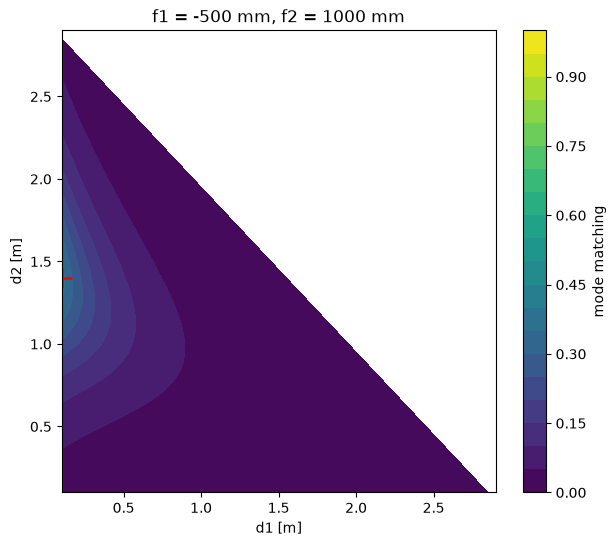

In [5]:
# The lens focal lengths (change these to try lenses from your stock)
f1 = -500*mm
f2 = 1000*mm

L1.set_focal_length(f1)
L2.set_focal_length(f2)

# Scan d1, d2 under the constraint d1 + d2 < 3.0, running
# layout.trace() at each point. Compute the mode matching between the
# beam transmitted through the ITM and the cavity eigenmode with
# gauss.modeMatching(), and show the result as a contour plot.


def matching(d1, d2):
    '''Place the lenses at d1, d2, trace, and return the mode matching
    between the ITM-transmitted beam and the eigenmode'''
    # Move the lenses
    L1.HRcenter = [d1, 0]
    L2.HRcenter = [d1 + d2, 0]
    # Run the trace
    layout.trace()

    for b in layout.beams: # loop over the traced beam objects
        if b.name == 'ITM:t1': # pick out the ITM transmission
            return gauss.modeMatching(b.qx, q_rt)  # the mode matching
    return np.nan   # the beam never reached the ITM

step = 0.05
d1s = np.arange(0.1, 2.9 + 1e-9, step) # the d1 grid
d2s = np.arange(0.1, 2.9 + 1e-9, step) # the d2 grid
M = np.full((len(d2s), len(d1s)), np.nan) # the mode matching results

# loop over d1 and d2
for i, d1 in enumerate(d1s):
    for j, d2 in enumerate(d2s):
        if d1 + d2 < 3.0:
            M[j, i] = matching(d1, d2) # store the mode matching

# Put the lenses the scan moved back where they were
L1.HRcenter = [1.0, 0]
L2.HRcenter = [2.0, 0]
layout.trace()

# Locate the maximum of the mode matching
k = np.unravel_index(np.nanargmax(M), M.shape)
print('best: %.4f (d1 = %.2f m, d2 = %.2f m)'
      % (np.nanmax(M), d1s[k[1]], d2s[k[0]]))

# The contour plot
fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(d1s, d2s, M, levels=np.linspace(0, 1, 21), cmap='viridis')
fig.colorbar(cs, label='mode matching')
ax.plot(d1s[k[1]], d2s[k[0]], 'r+', ms=14, mew=2)
ax.set_xlabel('d1 [m]')
ax.set_ylabel('d2 [m]')
ax.set_title('f1 = %.0f mm, f2 = %.0f mm' % (f1/mm, f2/mm))
plt.show()

## Speeding it up: parallelising the scan

The scan above calls `layout.trace()` once per grid point, which
takes some ten seconds on the 0.05 m grid (about 1600 points). If the
map is to be redrawn many times while changing lenses, joblib can
spread the work over every CPU core for a several-fold speedup
(measured on a 20-core machine: 10.6 s to 1.7 s, with results
identical to the serial scan).

Three points:

- In a notebook on Windows the standard `multiprocessing` cannot ship
  functions defined in the notebook to its workers. **joblib** (the
  loky backend) carries the function itself, so the code can be
  written as it reads
- Each worker builds **its own private bench** in `build_bench()`, so
  no objects are shared between processes. The scan therefore never
  touches this notebook's `layout` or its viewer
- The unit of parallel work is **one column of the map**
  (`scan_row`), not one point. Handed out point by point, the
  interprocess overhead would beat the computation

The worker processes take a few seconds to start the first time and
are reused by later runs of the cell, so the second scan onwards,
with a different f1, f2, is the fastest.

best: 0.9973 (d1 = 0.35 m, d2 = 0.50 m)


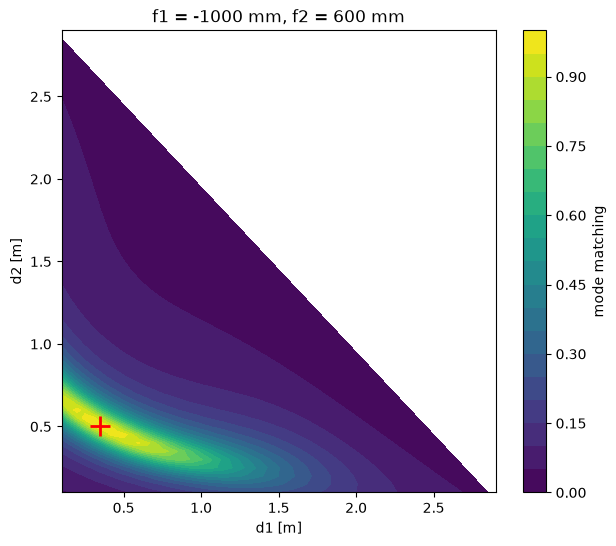

In [6]:
# The same scan as the cell above, parallelised over every CPU core
# with joblib
f1 = -1000*mm
f2 = 600*mm

L1.set_focal_length(f1)
L2.set_focal_length(f2)

import matplotlib.pyplot as plt
from joblib import Parallel, delayed

x_ITM = 3.0   # position of the ITM's HR surface

def build_bench(f1, f2):
    '''A worker's private copy of the bench built above'''
    itm = opt.Mirror(HRcenter=[x_ITM, 0], normAngleHR=0, diameter=1*inch,
                     thickness=6*mm, wedgeAngle=0.0, inv_ROC_HR=1./R1,
                     Refl_HR=0.9, Trans_HR=0.1, name='ITM')
    itm.HRtransmissive = True
    itm.term_on_HR = True
    etm = opt.Mirror(HRcenter=[x_ITM + L_cav, 0], normAngleHR=np.pi,
                     diameter=1*inch, thickness=6*mm, wedgeAngle=0.0,
                     inv_ROC_HR=1./R2, Refl_HR=1.0, Trans_HR=0.0, name='ETM')
    l1 = opt.Lens(f=f1, HRcenter=[1, 0], normAngleHR=pi,
                  diameter=1*inch, thickness=6*mm, name='L1')
    l2 = opt.Lens(f=f2, HRcenter=[2, 0], normAngleHR=pi,
                  diameter=1*inch, thickness=6*mm, name='L2')
    lay = OpticalLayout(name='scan')
    for m in [l1, l2, itm, etm]:
        lay.add_optics(m)
    lay.add_source(beam.GaussianBeam(
        q0=gauss.InvROCandW2q(invROC=0.0, w=w0_laser, wl=wl),
        wl=wl, pos=[0, 0], dirAngle=0.0, name='laser'))
    lay.rules = TraceRules(order=0, power_threshold=1e-4)
    return lay, l1, l2

def scan_row(f1, f2, d1, d2_list):
    '''One column of the map: d1 fixed, every valid d2'''
    lay, l1, l2 = build_bench(f1, f2)
    out = []
    for d2 in d2_list:
        l1.HRcenter = [d1, 0]
        l2.HRcenter = [d1 + d2, 0]
        lay.trace()
        val = np.nan   # stays NaN if the beam never reached the ITM
        for b in lay.beams:
            if b.name == 'ITM:t1':
                # Propagate the eigenmode's q to where the transmitted
                # beam starts before comparing
                q_eig = q_rt + (b.pos[0] - x_ITM)
                val = gauss.modeMatching(b.qx, q_eig)
                break
        out.append(val)
    return out

step = 0.05
d1s = np.arange(0.1, 2.9 + 1e-9, step)
d2s = np.arange(0.1, 2.9 + 1e-9, step)

rows = Parallel(n_jobs=-1)(
    delayed(scan_row)(f1, f2, d1, [d2 for d2 in d2s if d1 + d2 < 3.0])
    for d1 in d1s)

M = np.full((len(d2s), len(d1s)), np.nan)
for i, (d1, row) in enumerate(zip(d1s, rows)):
    valid = [j for j, d2 in enumerate(d2s) if d1 + d2 < 3.0]
    for j, val in zip(valid, row):
        M[j, i] = val

k = np.unravel_index(np.nanargmax(M), M.shape)
print('best: %.4f (d1 = %.2f m, d2 = %.2f m)'
      % (np.nanmax(M), d1s[k[1]], d2s[k[0]]))

fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(d1s, d2s, M, levels=np.linspace(0, 1, 21), cmap='viridis')
fig.colorbar(cs, label='mode matching')
ax.plot(d1s[k[1]], d2s[k[0]], 'r+', ms=14, mew=2)
ax.set_xlabel('d1 [m]')
ax.set_ylabel('d2 [m]')
ax.set_title('f1 = %.0f mm, f2 = %.0f mm' % (f1/mm, f2/mm))
plt.show()

# Pinning down d1, d2 by optimisation

The contour map is a 0.05 m grid, enough to find a starting point;
from here the work goes to an optimiser. Starting from `d1_init`,
`d2_init` read off the map, minimise 1 - matching with
`scipy.optimize.minimize` (Nelder-Mead).

- The cost function reuses `matching()` from above. One trace takes a
  few milliseconds and the optimisation needs of the order of a
  hundred evaluations, so no parallelism is needed here
- Nelder-Mead uses no derivatives, which suits a cost that comes out
  of a trace and has no gradient formula
- The constraints (positive lens separations, L2 short of the ITM)
  are a penalty: outside them the cost is the worst value, 1. **If
  the optimum comes back pinned to a constraint boundary**, that lens
  pair has no true optimum inside the constraints, and a different
  pair of focal lengths is the better move

An example: with f1 = 500 mm, f2 = -500 mm the map is bright around
d1 = 1.4, d2 = 0.4. Started there, 64 traces reach
matching = 1.000000, so this pair can be matched perfectly by
positioning alone.

In [7]:
from scipy.optimize import minimize

# Initial values read off the contour map
d1_init = d1s[k[1]]
d2_init = d2s[k[0]]

def cost(x):
    d1, d2 = x
    # Constraints: positive separations, and L2 short of the ITM with
    # a little margin. Outside them the cost is the worst value;
    # matching lies in 0..1, so that is 1.
    if d1 < 0.05 or d2 < 0.05 or d1 + d2 > 2.95:
        return 1.0
    return 1.0 - matching(d1, d2)

res = minimize(cost, [d1_init, d2_init], method='Nelder-Mead',
               options=dict(xatol=1e-4, fatol=1e-7))
d1_opt, d2_opt = res.x

print('initial   : d1 = %.3f m, d2 = %.3f m -> matching %.4f'
      % (d1_init, d2_init, matching(d1_init, d2_init)))
print('optimised : d1 = %.4f m, d2 = %.4f m -> matching %.6f'
      % (d1_opt, d2_opt, matching(d1_opt, d2_opt)))
print('converged in %d traces (%s)' % (res.nfev, res.message))

# Place the lenses at the optimum and trace again, so the viewer
# shows the optimised bench. The semicolon mutes the returned beam
# list, whose repr carries memory addresses that change on every run.
L1.HRcenter = [d1_opt, 0]
L2.HRcenter = [d1_opt + d2_opt, 0]
layout.trace();

initial   : d1 = 0.350 m, d2 = 0.500 m -> matching 0.9973
optimised : d1 = 0.3685 m, d2 = 0.4973 m -> matching 1.000000
converged in 43 traces (Optimization terminated successfully.)


# Checking in the GUI

Pick a beam near the ITM surface and confirm that its ROC is close
to 2.5 m, the ROC of the ITM. Do the same on the ETM: the mirror's
ROC and the beam's ROC agree there too. (A beam that ends on a
surface sits under the element itself; clicking the same spot
repeatedly steps from the element to the beams under it.)

In [8]:
layout.show()